In [2]:
import numpy as np
import matplotlib.pyplot as plt

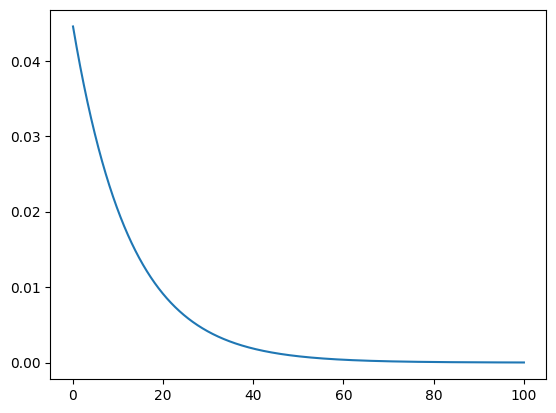

In [11]:
def R_10(r):
    a = 4 * np.pi # m
    return 2 * a**(-3/2) * np.exp(-r/a)

r = np.linspace(0.1,100,10001)
plt.plot(r, R_10(r))

In [12]:
def E(n):
    return -1 / (32 * np.pi**2 * n**2)

def f(v, r, n, l):
    u = v[0]
    w = v[1]

    K = (l*(l-1)/r**2) - 2*E(n) - 1/(2*np.pi*r)

    fu = w
    fw = K * u

    return np.array([fu,fw])

print(E(1), E(2))

-0.0031662869888230555 -0.0007915717472057639


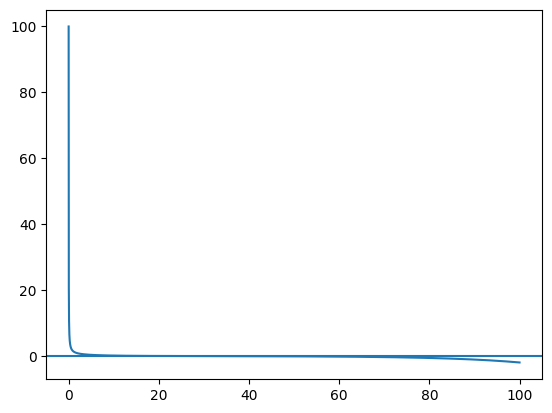

In [16]:
principle = 1
l = 0

r_i = 0.01
r_f = 100
n = 10001
h = (r_f - r_i) / (n - 1)

r = np.linspace(r_i,r_f,n)

u = np.zeros(n)
w = np.zeros(n)
u[0]=1
w[0]=1

v = np.array([u[0],w[0]])

for i in range(n-1):
    k1 = f(v,r[i],principle,l)
    k2 = f(v+k1*h/2, r[i]+h/2,principle,l)
    k3 = f(v+k2*h/2, r[i]+h/2,principle,l)
    k4 = f(v+k3*h, r[i]+h,principle,l)

    v = v + h*(k1+2*k2+2*k3+k4)/6

    u[i+1] = v[0]
    w[i+1] = v[1]

radial = u/r
plt.plot(r,radial)
plt.axhline(y=0)